# LSN-1.2 — Model I/O: What Goes In, What Comes Out

| | |
|---|---|
| **Lesson** | `LSN-1.2` — Module `MOD-1` (ML Literacy), Weeks 1–2 |
| **Serves** | `OUT-1.2` — *say what each major model type takes in and kicks out, and interpret its outputs* |
| **Duration** | 60 min session (15 + 30 + 15) + 20 min pre-work |
| **Verified by** | `ASM-1` — scenario quiz |
| **Homework** | **None** — keep your corrected "0.73" sentence; `LSN-1.3`'s pre-work is next |
| **Lesson plan** | `program/lessons/LSN-1.2-model-io.md` |

**The skill this hour installs.** `LSN-1.1` taught you to name the job. This hour is the next sentence out of
your mouth: **what does that model eat, what does it emit, and how do you read the thing it emits without
over- or under-claiming?** The misconception being killed is the one that costs the most in a client meeting:
**a model output is not a verdict.** A probability is not a fact, a number is meaningless without its units, a
cluster id has no meaning until a human names it, and a ranking is only ever relative. Say one of those four
sentences well and you sound like the senior person in the room; say "the model says 0.73, so it'll close" and
you have just made a promise the model never made.

**What this notebook is.** Not a lab. The session is a talk, a demo and a role-play; this is your **companion
and your workspace**: the pre-work you submit, one concrete training table you can point at, **four real model
outputs shown raw and then read line by line**, and the "0.73" drill with its answer key. Every model here is
three lines of scikit-learn on synthetic data and fits in milliseconds — a **prop**, there to make the output
*shape* concrete. **No accuracy claim in this notebook means anything**; whether a model is any good is
`LSN-1.3`, which is the next hour and the natural next question.

### The I/O card — the one screen worth keeping

| Job | Takes in | Kicks out | Read it as | Trap |
|---|---|---|---|---|
| **Classify** | one row of features | a **label** + a probability per label | the label is the *argmax*; the probability underneath is the real output | the threshold that turns the probability into a label is a **business** choice |
| **Propensity** | one row of features | **one probability, 0–1** | a long-run frequency for rows like this one | reading it as a verdict on *this* row (the whole drill) |
| **Regress** | one row of features | **one number, with units** | the number *and* its typical miss | a number with no units and no miss is not an answer |
| **Cluster** | features, **no label column** | a **group id** (0, 1, 2 …) | a nominal name, not a rank or a score | id `2` is not "better" than id `1`, and the ids move if you re-run |
| **Recommend** | interaction history + context | a **ranked short list** with relative scores | rank 1 beats rank 2 — nothing more | reading the score as a probability; ranking by the wrong column |

### How to run this

1. Kernel: the repo `.venv` (Python 3.12). From the repo root: `.venv/bin/jupyter lab`.
2. **Run All** once, top to bottom, before the session. Expected runtime: **a few seconds** — every fit in
   here is a few hundred synthetic rows. Every cell is safe to run unfilled: the fill-in cells tell you what is
   missing instead of raising (`SI-11`), so a fresh run is always clean.
3. Two cells save an artifact to `outputs/lsn-1.2/` (gitignored, stays on your machine): your **pre-work
   sentence** and your **drill answers**.
4. Order matters in exactly one place: fill in the drill cell **before** running the answer-key cell under it.
   The key is a reveal, not a hint.

## Setup — imports, palette, and the three rules this notebook obeys

- **Everything is seeded** (`SI-3`). Each example builds its own generator from its own pinned seed, so any
  single cell can be re-run in any order and give the same numbers back. Two executions of this notebook
  produce byte-identical output — including the cluster ids, which is a point the safari makes on purpose.
- **Every chart uses the VSP palette**, drops its top/right spines and labels its axes.
- **The models are props.** A `LogisticRegression` on 900 synthetic deals exists to produce a *real array with
  a real shape*, so that when you say "the model kicks out a probability" you have seen the object. Nothing in
  here is evidence that any model works.

**One stage-managed thing, disclosed up front.** Three rows of the pipeline table in the safari were
constructed so that the model's own output lands on the numbers the lesson plan scripts — **0.73**, **0.51**
and **0.31**. The fit is real, the arithmetic is real, the feature values were chosen to hit those scores. That
is the only thing in this notebook that was reverse-engineered, and you would want to know.

In [1]:
# numpy (seeded generators + every synthetic feature table below)
import numpy as np
# pandas (training tables, pipeline frames, ranked lists - a recommender's output IS a table)
import pandas as pd
# matplotlib (three figures: the anatomy of a training table, the cluster scatter, what 0.73 looks like)
import matplotlib.pyplot as plt
# matplotlib patches (the drawn cells of the training-table diagram)
from matplotlib.patches import Rectangle
# scikit-learn: four trivial models, one per output shape (SI-24). Still nothing heavier -
# no transformers, no LLM libraries (MOD-2), no torch (LSN-1.4).
import sklearn
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
# stdlib textwrap (the answer key prints wrapped paragraphs, not 200-character lines)
import textwrap
# stdlib json / getpass / datetime (the two artifacts this notebook saves to outputs/)
import json
import getpass
from datetime import datetime, timezone
# stdlib pathlib (locate the repo root without hardcoding a path - SI-5)
from pathlib import Path

# --- VSP palette. Four data colours from the design system + one ink colour for
# --- reference lines, cell edges and annotation text (VSP navy-darkest).
VSP = {
    "navy":   "#59709c",  # navy-light      - features / primary series
    "green":  "#65a74e",  # green           - second series
    "yellow": "#ffe86b",  # yellow          - the label column, and anything highlighted
    "mint":   "#97f377",  # green-lightest  - third series
    "ink":    "#2b374d",  # navy-darkest    - lines, edges, text
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.edgecolor": VSP["ink"],
    "axes.labelcolor": VSP["ink"],
    "text.color": VSP["ink"],
    "xtick.color": VSP["ink"],
    "ytick.color": VSP["ink"],
    "legend.frameon": False,
})

# --- Show full float precision where the raw output is the teaching point, and keep
# --- wide frames on one line so the projector shows a table, not a wrapped mess.
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 24)


def find_repo_root(start: Path) -> Path:
    """Walk up from `start` to the directory holding src/ and README.md (mirrors src/utils/pathing.py)."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise ValueError("Repo root not found - are you running inside the VSP-AI-ML-Training clone?")


REPO_ROOT = find_repo_root(Path.cwd())
OUT_DIR = REPO_ROOT / "outputs" / "lsn-1.2"      # gitignored via outputs/lsn-*/ (SI-4)

# --- The five output shapes this lesson names, and the words people actually type for them.
# --- Used by the pre-work checker, so "a probability", "odds" and "propensity score" all
# --- land on the same answer (SI-18: never grade on an exact string).
SHAPES = ("probability", "label", "number", "cluster id", "ranked list", "sentences")
_SHAPE_WORDS = {
    "probability": ("probability", "probabilities", "propensity", "odds", "likelihood", "chance",
                    "score between 0 and 1", "0-1", "0 to 1", "percent chance", "risk score"),
    "label": ("label", "labels", "class", "classes", "category", "categorical", "bucket", "flag",
              "yes/no", "yes or no", "true/false", "which team", "one of"),
    "number": ("number", "numeric", "quantity", "amount", "dollars", "dollar", "units", "days",
               "hours", "forecast", "value", "estimate", "regression output", "continuous"),
    "cluster id": ("cluster id", "cluster", "clusters", "group id", "group", "segment", "segments",
                   "cohort", "cluster number", "cluster label"),
    "ranked list": ("ranked list", "ranking", "rank", "ranked", "top-n", "top n", "top 5", "top five",
                    "shortlist", "short list", "ordered list", "list of recommendations", "recommendations"),
    "sentences": ("sentences", "sentence", "text", "words", "prose", "an answer", "a draft", "summary",
                  "paragraph", "generated text"),
}


def normalize_shape(text: str) -> str:
    """Map whatever the participant typed to one of SHAPES, or '' if it is not recognisable.

    Longest match wins, so 'cluster id' beats the bare 'id' and 'ranked list' beats 'list'.
    """
    t = " ".join(str(text).strip().lower().replace("_", " ").replace("/", " / ").split())
    if not t:
        return ""
    best, best_len = "", 0
    for shape, words in _SHAPE_WORDS.items():
        for w in words:
            if w in t and len(w) > best_len:
                best, best_len = shape, len(w)
    return best


def hits(text: str, patterns) -> list:
    """Substring probe used by the drill grader: which of `patterns` appear in `text`."""
    t = " ".join(str(text).lower().split())
    return [p for p in patterns if p in t]


def wrap(label: str, text: str, width: int = 104, pad: int = 12) -> None:
    """Print `label` + wrapped `text` in the answer-key idiom used across this program."""
    print(textwrap.fill(text, width=width, initial_indent=f"  {label:<{pad - 2}}",
                        subsequent_indent=" " * pad))


print(f"numpy {np.__version__} - pandas {pd.__version__} - matplotlib {plt.matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__}   <- four props: LogisticRegression, LinearRegression, "
      f"KMeans, NearestNeighbors")
print(f"Repo root  : {REPO_ROOT}")
print(f"Artifacts  : {OUT_DIR.relative_to(REPO_ROOT)}/  (created on first save; gitignored)")
print("[PASS] Setup complete - palette loaded, paths resolved, five output shapes registered.")

numpy 2.5.1 - pandas 3.0.5 - matplotlib 3.11.1
scikit-learn 1.9.0   <- four props: LogisticRegression, LinearRegression, KMeans, NearestNeighbors
Repo root  : /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training
Artifacts  : outputs/lsn-1.2/  (created on first save; gitignored)
[PASS] Setup complete - palette loaded, paths resolved, five output shapes registered.


---

# Pre-work — do this **before** the session

*20 minutes total. Mandatory: no pre-work, no seat.*

| # | Task | Time | What to bring |
|---|---|---|---|
| 1 | Read the sections on **model types and reading outputs**: the session deck `program/lessons/decks/LSN-1.2-model-io.html`, plus the **I/O card** at the top of this notebook | 15 min | Nothing to submit |
| 2 | Write one sentence: what do you think a "lead score of 0.73" means, exactly? | 5 min | Your sentence — it gets stress-tested in the drill |
| 3 | **Bring your triaged ask from `LSN-1.1`** (`outputs/lsn-1.1/prework_*.json`). The question this hour asks of it: **what would that model take in, and what would it kick out?** | — | Three lines in the cell below |

**About the source material.** The lesson plan points task 1 at Tyler's original ML literacy deck
(`PROGRAM_PLAN.md` §8). That deck is not in this repo — same call `LSN-0.4` and `LSN-1.1` made: **the session
deck for this lesson is the canonical version.** `program/lessons/decks/LSN-1.2-model-io.html` carries the
features-and-labels material, the four-stop output safari and the interpretation drill. Read that plus the I/O
card above. Don't go hunting for a file.

### Task 2 — write the sentence badly on purpose

Do **not** research it. Write what you actually believe right now, in one sentence, and save it. Most first
attempts say *"a 73% chance it closes"* and stop there — which is nearly right and still gets you in trouble,
because the sentence you did not write is the one the VP of Sales needs. The drill reads these back before the
model answer appears, and the gap between the two is the lesson.

### Task 3 — the thread from last week

Your `LSN-1.1` ask named a **job**. A job implies a table: some columns you would feed it, one column you are
trying to predict (or the admission that no such column exists), and one row of output. Three lines below. If
you cannot name the label column, say `none` — that is a real and common answer, and it is the whole reason
`LSN-1.6` exists.

In [2]:
# --- Pre-work tasks 2 and 3. Run the cell when you are done. It never crashes and it never
#     grades you - it tells you which line still needs work, then saves your sentence so the
#     drill can read it back to you.
#
#     Weak (task 2):   "it means the lead is good"
#     Honest (task 2): "I think it means the model reckons there is a 73% chance this lead buys,
#                       though I am not sure whether that is per-lead or across a whole batch"

MY_073_SENTENCE = ""    # task 2: what does a "lead score of 0.73" mean, exactly? (40+ characters)

# Task 3 - your LSN-1.1 ask, turned into a table and an output shape.
MY_ASK_JOB = ""         # the job you triaged it as: classify | cluster | regress | propensity | recommend
MY_FEATURES = ""        # 3+ columns you would feed it, comma-separated, in the client's own vocabulary
MY_LABEL = ""           # the column you are predicting - or the word "none" if nobody wrote it down
MY_OUTPUT_SHAPE = ""    # what ONE row of output looks like: probability | label | number | cluster id |
#                         ranked list | sentences

# ---------------------------------------------------------------- checker (do not edit below)
MIN_SENTENCE = 40
_sent = MY_073_SENTENCE.strip()
_job = " ".join(MY_ASK_JOB.strip().lower().split())
_feats = [f.strip() for f in MY_FEATURES.replace(";", ",").split(",") if f.strip()]
_label = " ".join(MY_LABEL.strip().lower().split())
_shape = normalize_shape(MY_OUTPUT_SHAPE)

_todo = []
if len(_sent) < MIN_SENTENCE:
    _todo.append(f"MY_073_SENTENCE: {MIN_SENTENCE}+ characters of what you actually believe, before the "
                 f"session tells you. Being wrong here costs nothing and is the point of the exercise.")
if not _job:
    _todo.append("MY_ASK_JOB: the job you triaged your LSN-1.1 ask as (classify / cluster / regress / "
                 "propensity / recommend). Open outputs/lsn-1.1/prework_*.json if you have forgotten it.")
if len(_feats) < 3:
    _todo.append(f"MY_FEATURES: 3+ columns, comma-separated (you have {len(_feats)}). Use the client's own "
                 f"words for them - 'days since last site visit', not 'temporal_feature_7'.")
if not _label:
    _todo.append("MY_LABEL: the column you are predicting, or the word 'none'. 'none' is a legitimate "
                 "answer - it means either a clustering job or a labelling project nobody has priced.")
if not _shape:
    _todo.append("MY_OUTPUT_SHAPE: one of " + " | ".join(SHAPES) + ".  ('a probability', 'odds', 'top 5', "
                 "'group id' and friends all normalise fine - a blank does not.)")

# Advisory lint. Never blocks the save; these are the arguments the session is made of.
_advice = []
if _shape and _label == "none" and _shape != "cluster id":
    _advice.append(f"You said there is no label column but the output is a {_shape}. Those two do not go "
                   f"together: with no labelled history the only thing a model can hand you is a group id "
                   f"(or a ranking built from co-occurrence). Worth resolving before the session - it is "
                   f"usually the most interesting thing about a real ask.")
if _shape == "probability" and _job.startswith(("class", "sort")):
    _advice.append("You triaged it as classify and expect a probability out. That is not a contradiction - "
                   "every classifier has probabilities under its labels (safari stop 1). The question is "
                   "which one the client acts on, and that is what names the job (LSN-1.1's first boundary).")
if _feats and any(w in " ".join(_feats).lower() for w in
                  ("outcome", "result", "closed", "won", "churned", "actual", "final", "resolved")):
    _advice.append("One of your feature names sounds like it is recorded AFTER the thing you are predicting "
                   "('closed', 'won', 'final', 'resolved'). If so it is leakage - the model looks brilliant "
                   "in the demo and useless in production. Segment 1 covers this; check the column's "
                   "timestamp, not its name.")

if _todo:
    for _t in _todo:
        print(textwrap.fill(f"[TODO] {_t}", width=104, subsequent_indent="       "))
    print("\n       Nothing is saved until those are filled in. Twenty minutes total, and the sentence in"
          "\n       task 2 is the one the drill stress-tests - so write it before you read the deck's"
          "\n       interpretation slides, not after.")
else:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    _path = OUT_DIR / f"prework_{getpass.getuser()}.json"
    _path.write_text(json.dumps({
        "lesson": "LSN-1.2", "serves": ["OUT-1.2"], "assessment": "ASM-1",
        "artifact": "pre-work: the pre-session '0.73' sentence + the I/O of your LSN-1.1 ask",
        "user": getpass.getuser(),
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
        "sentence_0_73": _sent,
        "ask_job": _job, "features": _feats, "label": _label, "output_shape": _shape,
    }, indent=2))
    print(f"[PASS] Sentence on file ({len(_sent)} characters). Your ask: {_job.upper() or '(none)'} - "
          f"{len(_feats)} features, label '{_label}', one row of output = {_shape.upper()}.")
    print(f"[SAVED] {_path.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
    print("        Do not edit it after the session. The point is to compare it with what you write in")
    print("        the drill cell later - the delta is the outcome.\n")
    if _advice:
        print("       [advisory only - your save is already done]")
        for _a in _advice:
            print(textwrap.fill(f"        - {_a}", width=104, subsequent_indent="          "))
    else:
        print("       No flags. Bring the ask to the session; segment 1 turns it into a table.")

[TODO] MY_073_SENTENCE: 40+ characters of what you actually believe, before the session tells you. Being
       wrong here costs nothing and is the point of the exercise.
[TODO] MY_ASK_JOB: the job you triaged your LSN-1.1 ask as (classify / cluster / regress / propensity /
       recommend). Open outputs/lsn-1.1/prework_*.json if you have forgotten it.
[TODO] MY_FEATURES: 3+ columns, comma-separated (you have 0). Use the client's own words for them -
       'days since last site visit', not 'temporal_feature_7'.
[TODO] MY_LABEL: the column you are predicting, or the word 'none'. 'none' is a legitimate answer - it
       means either a clustering job or a labelling project nobody has priced.
[TODO] MY_OUTPUT_SHAPE: one of probability | label | number | cluster id | ranked list | sentences.  ('a
       probability', 'odds', 'top 5', 'group id' and friends all normalise fine - a blank does not.)

       Nothing is saved until those are filled in. Twenty minutes total, and the sentence in

---

# Segment 1 — Features and labels *(15 min)*

## What training data actually is

Strip away the vocabulary and every supervised model in the world is fed the same object: **a table.**

| The word | What it actually is | In a client's system it is… |
|---|---|---|
| **row** / *example* / *sample* | one thing you want an answer about | one deal, one shipment, one ticket, one site visit |
| **column** / *feature* / *predictor* | one fact you know about that thing **before** the answer arrives | seats, logins last 30 days, days since last contact |
| **the label column** / *target* / *y* | the answer, written down, for **past** rows | `closed?`, `delivered_late`, `resolved_by_team`, `annual_spend` |

And the definition that matters in a discovery call, the one from `LSN-1.1`:

> **Supervised** = the label column exists. **Unsupervised** = it doesn't.

That is the whole distinction. Not model families, not neural networks, not "AI maturity" — *does a human, at
some point, write the answer down next to the example?* If yes, you have classify / propensity / regress. If
no, you have cluster, or you have a **labelling project** nobody has priced yet.

Below is one small CRM table. Ten past deals, five feature columns, and two candidate label columns. It is
**hand-built rather than generated** so you can see the pattern with your own eyes — the safari's models fit a
few hundred rows of the same shape, where you cannot.

In [3]:
# --- One CRM table, ten past deals. Hand-written on purpose: no rng, nothing to re-seed,
#     and you can read the pattern off the screen. Everything else in this notebook is a
#     few hundred generated rows of exactly this shape.

CRM = pd.DataFrame([
    # account  seats logins_30d touches_30d days_since_contact demo_minutes annual_spend_$ closed?
    ("#3014",   240,      690,        9,             4,             41.0,      44_800.0,   "yes"),
    ("#3021",    35,       90,        2,            39,              5.5,           None,   "no"),
    ("#3033",   120,      480,        7,             9,             28.5,      31_600.0,   "yes"),
    ("#3040",    60,      150,        3,            26,             12.0,           None,   "no"),
    ("#3052",   310,     1180,       11,             2,             52.5,      58_900.0,   "yes"),
    ("#3061",    95,      240,        8,            31,             33.0,           None,   "no"),
    ("#3078",    45,      210,        5,            12,             22.0,      21_300.0,   "yes"),
    ("#3085",   180,      320,        2,            44,              8.0,           None,   "no"),
    ("#3090",    75,      610,       10,             6,             37.5,      26_700.0,   "yes"),
    ("#3097",   150,      300,        4,            21,             14.5,           None,   "no"),
], columns=["account", "seats", "logins_30d", "touches_30d", "days_since_contact",
            "demo_minutes", "annual_spend_$", "closed?"])

FEATURES = ["seats", "logins_30d", "touches_30d", "days_since_contact", "demo_minutes"]

print("THE TABLE, AS IT SITS IN THE CRM  (10 rows x 8 columns)")
display(CRM)

print(f"rows (examples)        : {len(CRM)}")
print(f"feature columns        : {len(FEATURES)}  -> {', '.join(FEATURES)}")
print(f"candidate label columns: 2  -> 'closed?' (a bucket) and 'annual_spend_$' (a number)")
print(f"label 'closed?'        : {CRM['closed?'].value_counts().to_dict()}  <- balanced here; almost never "
      f"is in real life (LSN-0.3's base rates)")
print()
print("Read the pattern off the screen: the deals that closed had MORE touches, FEWER days since the last")
print("contact and MORE demo minutes. Now look at #3061 - 8 touches, 33 demo minutes, and it lost anyway.")
print("That single row is why every output in this notebook is a probability and not a verdict: the pattern")
print("is a tendency, not a rule (LSN-0.4, cashed).")

THE TABLE, AS IT SITS IN THE CRM  (10 rows x 8 columns)


,account,seats,logins_30d,touches_30d,days_since_contact,demo_minutes,annual_spend_$,closed?
0,#3014,240,690,9,4,41.0,44800.0,yes
1,#3021,35,90,2,39,5.5,NaN,no
2,#3033,120,480,7,9,28.5,31600.0,yes
3,#3040,60,150,3,26,12.0,NaN,no
4,#3052,310,1180,11,2,52.5,58900.0,yes
5,#3061,95,240,8,31,33.0,NaN,no
6,#3078,45,210,5,12,22.0,21300.0,yes
7,#3085,180,320,2,44,8.0,NaN,no
8,#3090,75,610,10,6,37.5,26700.0,yes
9,#3097,150,300,4,21,14.5,NaN,no


rows (examples)        : 10
feature columns        : 5  -> seats, logins_30d, touches_30d, days_since_contact, demo_minutes
candidate label columns: 2  -> 'closed?' (a bucket) and 'annual_spend_$' (a number)
label 'closed?'        : {'yes': 5, 'no': 5}  <- balanced here; almost never is in real life (LSN-0.3's base rates)

Read the pattern off the screen: the deals that closed had MORE touches, FEWER days since the last
contact and MORE demo minutes. Now look at #3061 - 8 touches, 33 demo minutes, and it lost anyway.
That single row is why every output in this notebook is a probability and not a verdict: the pattern
is a tendency, not a rule (LSN-0.4, cashed).


## The same table twice — the label column is the only difference

This is the slide the lesson plan asks for, and it is worth doing slowly, because two projects that look
identical to a client are decided by whether one column is present.

- **With `closed?`** → this is **propensity / classification training data**. Five features in, one known
  answer per row, and a model can learn the mapping.
- **Without any label column** → the same accounts are now **segmentation data**. Nothing to learn *toward*;
  all a model can do is notice which rows resemble which other rows and hand you group ids.

Then the third move, which is the one that surprises people: **swap which column is the label.** Point the
model at `annual_spend_$` instead of `closed?` and, with the same rows and the same features, you have a
**regression** project — the safari's stop 2. One table, three jobs, decided entirely by which column you
circle.

### The two questions that decide feasibility, in one screenshot

1. **Is the label column populated for enough past rows?** Look at `annual_spend_$` below: it is blank on
   every row where `closed?` is `no`, because a deal that never closed never spent anything. So the spend model
   can only train on the five won deals — and that is a **survivorship** problem (`LSN-0.2`), not a modelling
   one.
2. **Was every feature known *before* the label?** `annual_spend_$` would be a spectacular feature for
   predicting `closed?` — and using it is **leakage**: it is only recorded *after* the deal closes. A model fed
   that column scores ~100% in the demo and is worthless in production, because at prediction time the column
   is empty. The check is the column's **timestamp**, not its name, and asking for it in discovery is a senior
   move.

In [4]:
# --- The same ten accounts, three framings. Nothing is fitted here; this is pure table anatomy.

supervised = CRM[["account"] + FEATURES + ["closed?"]]
unsupervised = CRM[["account"] + FEATURES]
regression = CRM[["account"] + FEATURES + ["annual_spend_$"]]

print("=" * 104)
print("1. SUPERVISED - the label column exists ('closed?').  Job: propensity / classification")
print("=" * 104)
display(supervised)

print("=" * 104)
print("2. UNSUPERVISED - the same rows with no answer column at all.  Job: cluster")
print("=" * 104)
display(unsupervised)

print("=" * 104)
print("3. SAME TABLE, DIFFERENT LABEL COLUMN ('annual_spend_$').  Job: regression")
print("=" * 104)
display(regression)

# --- The two feasibility checks, run as code rather than asserted in prose.
_n_label = int(CRM["annual_spend_$"].notna().sum())
print(f"[CHECK] label 'annual_spend_$' is populated on {_n_label} of {len(CRM)} rows - and exactly the "
      f"{_n_label} that closed.")
print("        Nobody spent money on a deal that never closed, so the spend model trains on won deals only.")
print("        That is survivorship (LSN-0.2), and it is the first thing to say out loud about a spend model.")
print()
_leaky = "annual_spend_$"
print(f"[CHECK] would '{_leaky}' be a good feature for predicting 'closed?' -> yes, perfectly: it is "
      f"non-empty\n        for every 'yes' and empty for every 'no'.")
print("        Which is exactly why it is LEAKAGE. It is recorded AFTER the outcome, so at prediction time")
print("        (an open deal, this morning) the column is blank. A model built on it demos at ~100% accuracy")
print("        and is worth nothing. Ask for the column's TIMESTAMP, not its name.")
print()
print("[PASS] One table, three jobs. The client's data did not change; the column you circle did.")

1. SUPERVISED - the label column exists ('closed?').  Job: propensity / classification


,account,seats,logins_30d,touches_30d,days_since_contact,demo_minutes,closed?
0,#3014,240,690,9,4,41.0,yes
1,#3021,35,90,2,39,5.5,no
2,#3033,120,480,7,9,28.5,yes
3,#3040,60,150,3,26,12.0,no
4,#3052,310,1180,11,2,52.5,yes
5,#3061,95,240,8,31,33.0,no
6,#3078,45,210,5,12,22.0,yes
7,#3085,180,320,2,44,8.0,no
8,#3090,75,610,10,6,37.5,yes
9,#3097,150,300,4,21,14.5,no


2. UNSUPERVISED - the same rows with no answer column at all.  Job: cluster


,account,seats,logins_30d,touches_30d,days_since_contact,demo_minutes
0,#3014,240,690,9,4,41.0
1,#3021,35,90,2,39,5.5
2,#3033,120,480,7,9,28.5
3,#3040,60,150,3,26,12.0
4,#3052,310,1180,11,2,52.5
5,#3061,95,240,8,31,33.0
6,#3078,45,210,5,12,22.0
7,#3085,180,320,2,44,8.0
8,#3090,75,610,10,6,37.5
9,#3097,150,300,4,21,14.5


3. SAME TABLE, DIFFERENT LABEL COLUMN ('annual_spend_$').  Job: regression


,account,seats,logins_30d,touches_30d,days_since_contact,demo_minutes,annual_spend_$
0,#3014,240,690,9,4,41.0,44800.0
1,#3021,35,90,2,39,5.5,NaN
2,#3033,120,480,7,9,28.5,31600.0
3,#3040,60,150,3,26,12.0,NaN
4,#3052,310,1180,11,2,52.5,58900.0
5,#3061,95,240,8,31,33.0,NaN
6,#3078,45,210,5,12,22.0,21300.0
7,#3085,180,320,2,44,8.0,NaN
8,#3090,75,610,10,6,37.5,26700.0
9,#3097,150,300,4,21,14.5,NaN


[CHECK] label 'annual_spend_$' is populated on 5 of 10 rows - and exactly the 5 that closed.
        Nobody spent money on a deal that never closed, so the spend model trains on won deals only.
        That is survivorship (LSN-0.2), and it is the first thing to say out loud about a spend model.

[CHECK] would 'annual_spend_$' be a good feature for predicting 'closed?' -> yes, perfectly: it is non-empty
        for every 'yes' and empty for every 'no'.
        Which is exactly why it is LEAKAGE. It is recorded AFTER the outcome, so at prediction time
        (an open deal, this morning) the column is blank. A model built on it demos at ~100% accuracy
        and is worth nothing. Ask for the column's TIMESTAMP, not its name.

[PASS] One table, three jobs. The client's data did not change; the column you circle did.


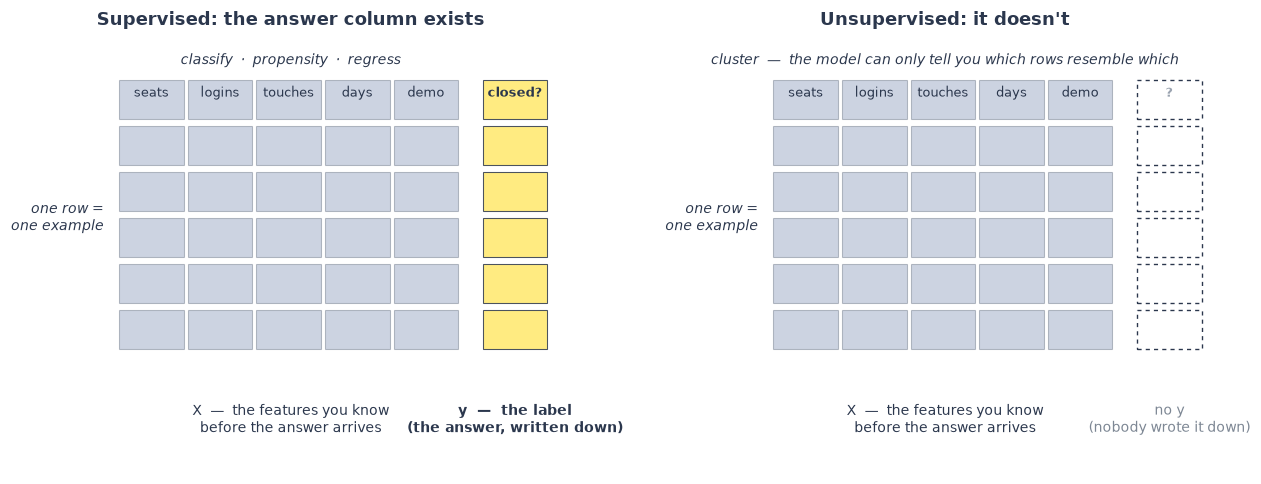

Two sentences that use this picture in a discovery call:
  "Everything we would build starts as one table: a row per deal, a column per thing you already
   know, and one column with the answer in it for deals that are finished."
  "So the question that decides the whole project is: who fills in that last column, and how
   many rows of it do you already have?"   <- LSN-1.6 spends an hour on exactly this.


In [5]:
# --- Figure: the anatomy of a training table, and the one difference between supervised
# --- and unsupervised. A diagram, not data - drawn once, in the VSP palette.

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.5))
N_ROWS_D, N_FEAT_D = 6, 5
CELL_W, CELL_H = 1.0, 0.62
FEATURE_HEADS = ["seats", "logins", "touches", "days", "demo"]


def draw_matrix(ax, with_label: bool, title: str, subtitle: str) -> None:
    """Draw a feature matrix (navy) and, optionally, a label column (yellow)."""
    for r in range(N_ROWS_D):
        for c in range(N_FEAT_D):
            ax.add_patch(Rectangle((c * CELL_W, -r * CELL_H), CELL_W * 0.94, CELL_H * 0.86,
                                   facecolor=VSP["navy"], alpha=0.30, edgecolor=VSP["ink"],
                                   linewidth=0.7))
        xl = N_FEAT_D * CELL_W + 0.30
        if with_label:
            ax.add_patch(Rectangle((xl, -r * CELL_H), CELL_W * 0.94, CELL_H * 0.86,
                                   facecolor=VSP["yellow"], alpha=0.85, edgecolor=VSP["ink"],
                                   linewidth=0.7))
        else:
            ax.add_patch(Rectangle((xl, -r * CELL_H), CELL_W * 0.94, CELL_H * 0.86,
                                   facecolor="none", edgecolor=VSP["ink"], linewidth=0.9,
                                   linestyle=(0, (3, 3))))
    # column headers
    for c, name in enumerate(FEATURE_HEADS):
        ax.text(c * CELL_W + CELL_W * 0.47, CELL_H * 0.42, name, ha="center", va="bottom",
                fontsize=8.6, color=VSP["ink"], rotation=0)
    xl = N_FEAT_D * CELL_W + 0.30
    ax.text(xl + CELL_W * 0.47, CELL_H * 0.42, "closed?" if with_label else "?", ha="center",
            va="bottom", fontsize=8.6, fontweight="bold",
            color=VSP["ink"] if with_label else "#9aa3b0")
    # row / matrix annotations
    ax.text(-0.22, -(N_ROWS_D - 1) * CELL_H / 2 + CELL_H * 0.35, "one row =\none example",
            ha="right", va="center", fontsize=9, color=VSP["ink"], style="italic")
    ax.text(N_FEAT_D * CELL_W / 2, -N_ROWS_D * CELL_H - 0.10, "X  —  the features you know\nbefore the "
            "answer arrives", ha="center", va="top", fontsize=9.2, color=VSP["ink"])
    ax.text(xl + CELL_W * 0.47, -N_ROWS_D * CELL_H - 0.10,
            "y  —  the label\n(the answer, written down)" if with_label
            else "no y\n(nobody wrote it down)",
            ha="center", va="top", fontsize=9.2, fontweight="bold" if with_label else "normal",
            color=VSP["ink"] if with_label else "#7d8794")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=30)
    ax.text(0.5, 1.008, subtitle, transform=ax.transAxes, ha="center", va="bottom", fontsize=9.4,
            style="italic", color=VSP["ink"])
    ax.set_xlim(-1.55, xl + CELL_W + 0.25)
    ax.set_ylim(-N_ROWS_D * CELL_H - 1.05, CELL_H * 1.05)
    ax.axis("off")


draw_matrix(axes[0], True, "Supervised: the answer column exists",
            "classify  ·  propensity  ·  regress")
draw_matrix(axes[1], False, "Unsupervised: it doesn't",
            "cluster  —  the model can only tell you which rows resemble which")
plt.tight_layout()
plt.show()

print("Two sentences that use this picture in a discovery call:")
print('  "Everything we would build starts as one table: a row per deal, a column per thing you already')
print('   know, and one column with the answer in it for deals that are finished."')
print('  "So the question that decides the whole project is: who fills in that last column, and how')
print('   many rows of it do you already have?"   <- LSN-1.6 spends an hour on exactly this.')

---

# Segment 2 — The output safari *(30 min)*

Four output types, four real fitted models, and for each one the same five moves:

| | |
|---|---|
| **1. Takes in** | the table shape it needs — and whether a label column has to exist |
| **2. Kicks out** | the **raw object**, printed exactly as Python hands it over. Not a paraphrase: the array. |
| **3. What it is** | read line by line — what the number *is*, in one sentence a client would accept |
| **4. What it is NOT** | the misreading that costs money. `0.73` is not a verdict; cluster `2` is not better than `1` |
| **5. Say this** | the one-sentence client-safe translation, and the "go deeper" notebook in this repo |

**A note on how these are produced** *(and a small deviation from the lesson plan, disclosed)*. The plan
specifies four outputs "pulled from repo notebooks, rendered ahead of time and shown side by side — not run
live." Written before this program had session notebooks. What you get instead is better for the room: the four
outputs are generated **live, here, from tiny seeded fits that finish instantly**, so nothing is a screenshot
someone has to trust — you can change a feature value and watch the output move. Each stop then points at the
matching **deeper notebook already in this repo** for anyone who wants the algorithm rather than the output
shape. Verified paths, printed at the end of the segment.

**The through-line:** all four stops live in the same CRM world as segment 1 — the same accounts, the same
columns, the same client. What changes across the four is only **the shape of the thing that comes back**.

## Stop 1 · A classifier / propensity model → **probabilities**

*Model: `LogisticRegression` on 900 past deals · label column: `closed?` · features: touches, days since
contact, demo minutes.*

This is the stop the whole lesson turns on, because it produces the number in the drill. Two things about it
that participants routinely get backwards:

- The **probability** is the model's real output. The **label** is a downstream decision — `predict()` is
  nothing more than "probability ≥ 0.5", and 0.5 is a default, not a truth. The cell below proves that by
  recomputing `predict()` from the probabilities by hand.
- The array has **one number per class**, and they sum to 1. `predict_proba` returns
  `[[P(no), P(yes)], …]` in the order of `model.classes_`. Reading column 0 when you meant column 1 is the
  most common bug in a first ML script, and it is silent — a 0.27 that looks like a plausible score.

In [6]:
# --- STOP 1: propensity / classification. 900 past deals with the answer recorded, then this
# --- morning's six open deals scored. Fit time: milliseconds.

rng = np.random.default_rng(730)
N_HIST = 900

# Past deals. The label exists because somebody in sales marked each one won or lost.
touches = rng.integers(1, 15, N_HIST)
days_since = rng.integers(1, 60, N_HIST)
demo_minutes = rng.normal(22, 9, N_HIST).clip(0, 75).round(1)
# A true relationship + real-world noise: more touches and more demo time help, going quiet hurts.
lin_true = 0.34 * (touches - 7) - 0.055 * (days_since - 20) + 0.035 * (demo_minutes - 22) + 0.15
closed_hist = rng.random(N_HIST) < 1 / (1 + np.exp(-lin_true))

X_hist = np.column_stack([touches, days_since, demo_minutes])
clf = LogisticRegression().fit(X_hist, closed_hist.astype(int))     # three lines, and that is the point

# This morning's pipeline review: six OPEN deals. No label column - that is what we are predicting.
PIPELINE = pd.DataFrame([
    ("#4191", 11,  6, 30.3),
    ("#4162", 10, 21, 18.4),
    ("#4127",  8, 28, 53.5),      # <- the deal in the drill. Feature values chosen to land on 0.73.
    ("#4155",  6, 22, 32.8),      # <- lands on 0.51 (curveball 1)
    ("#4108",  4, 13,  9.7),      # <- lands on 0.31 (the model answer's comparison)
    ("#4103",  3, 27,  6.7),
], columns=["deal", "touches_30d", "days_since_contact", "demo_minutes"])

X_open = PIPELINE[["touches_30d", "days_since_contact", "demo_minutes"]].to_numpy(dtype=float)

print("RAW OUTPUT 1 - clf.predict_proba(X_open), exactly as Python hands it over:")
print(repr(clf.predict_proba(X_open)))
print()
print(f"clf.classes_ = {clf.classes_}     <- column 0 is 'did not close', column 1 is 'closed'")
print(f"shape        = {clf.predict_proba(X_open).shape}   (6 deals x 2 classes; every row sums to "
      f"{clf.predict_proba(X_open).sum(axis=1)[0]:.1f})")
print()
print("RAW OUTPUT 2 - clf.predict(X_open), the same model asked for a label instead:")
print(repr(clf.predict(X_open)))

proba_yes = clf.predict_proba(X_open)[:, 1]
by_hand = (proba_yes >= 0.5).astype(int)
assert (by_hand == clf.predict(X_open)).all()          # predict() IS a threshold at 0.5, nothing more
print()
print("[CHECK] recomputing predict() by hand as (probability >= 0.5) reproduces it exactly.")
print("        So the LABEL is not a second output - it is the probability plus a threshold somebody chose.")

PIPELINE["score"] = proba_yes
PIPELINE["what the CRM shows"] = [f"{p:.2f}" for p in proba_yes]
PIPELINE["label at 0.50"] = np.where(clf.predict(X_open) == 1, "will close", "will not close")
PIPELINE["label at 0.75"] = np.where(proba_yes >= 0.75, "will close", "will not close")
print()
print("THIS MORNING'S PIPELINE REVIEW  (sorted as the client's dashboard sorts it)")
display(PIPELINE)

# Pin the three scripted numbers so a re-run either matches the lesson plan or fails loudly (SI-17).
_scores = dict(zip(PIPELINE["deal"], proba_yes))
assert round(_scores["#4127"], 2) == 0.73, _scores["#4127"]
assert round(_scores["#4155"], 2) == 0.51, _scores["#4155"]
assert round(_scores["#4108"], 2) == 0.31, _scores["#4108"]
print(f"[PASS] the drill's three numbers are real model output: #4127 -> {_scores['#4127']:.4f}, "
      f"#4155 -> {_scores['#4155']:.4f}, #4108 -> {_scores['#4108']:.4f}")
print(f"       The dashboard rounds to two places and shows 0.73. The raw float is "
      f"{_scores['#4127']:.8f}, and")
print("       every digit after the second is fiction - the model is not calibrated to eight decimals.")
print()
print("Look at the last two columns. Same six probabilities, two different thresholds, two different sets")
print("of 'will close' labels. Nothing about the model changed between those columns - the CLIENT changed.")

RAW OUTPUT 1 - clf.predict_proba(X_open), exactly as Python hands it over:
array([[0.0601102 , 0.9398898 ],
       [0.24640442, 0.75359558],
       [0.27000452, 0.72999548],
       [0.49001207, 0.50998793],
       [0.689986  , 0.310014  ],
       [0.89185088, 0.10814912]])

clf.classes_ = [0 1]     <- column 0 is 'did not close', column 1 is 'closed'
shape        = (6, 2)   (6 deals x 2 classes; every row sums to 1.0)

RAW OUTPUT 2 - clf.predict(X_open), the same model asked for a label instead:
array([1, 1, 1, 1, 0, 0])

[CHECK] recomputing predict() by hand as (probability >= 0.5) reproduces it exactly.
        So the LABEL is not a second output - it is the probability plus a threshold somebody chose.

THIS MORNING'S PIPELINE REVIEW  (sorted as the client's dashboard sorts it)


,deal,touches_30d,days_since_contact,demo_minutes,score,what the CRM shows,label at 0.50,label at 0.75
0,#4191,11,6,30.3,0.939890,0.94,will close,will close
1,#4162,10,21,18.4,0.753596,0.75,will close,will close
2,#4127,8,28,53.5,0.729995,0.73,will close,will not close
3,#4155,6,22,32.8,0.509988,0.51,will close,will not close
4,#4108,4,13,9.7,0.310014,0.31,will not close,will not close
5,#4103,3,27,6.7,0.108149,0.11,will not close,will not close


[PASS] the drill's three numbers are real model output: #4127 -> 0.7300, #4155 -> 0.5100, #4108 -> 0.3100
       The dashboard rounds to two places and shows 0.73. The raw float is 0.72999548, and
       every digit after the second is fiction - the model is not calibrated to eight decimals.

Look at the last two columns. Same six probabilities, two different thresholds, two different sets
of 'will close' labels. Nothing about the model changed between those columns - the CLIENT changed.


### Stop 1, read line by line

| | |
|---|---|
| **Takes in** | one row per deal; features that are all knowable **before** the deal resolves; a `closed?` label column for past rows |
| **Kicks out** | a `(n_deals, n_classes)` float array. For deal `#4127`: `[0.27000452, 0.72999548]` |
| **What it is** | the model's **estimated probability** that this deal closes, given the features it saw. If it is well calibrated, then across all the deals it scores near 0.73, about 73 in 100 close |
| **What it is NOT** | ① a verdict on `#4127` — 27 of every 100 lookalikes lose · ② the model's accuracy (that is a different number, and it is `LSN-1.3`) · ③ a *reason* — nothing here says *why* · ④ automatically a probability at all: see the tie below |
| **Say this** | *"It is a calibrated probability, not a prediction about this one deal. It says #4127 belongs near the top of your work list — and it says nothing about why, or about what to do next."* |
| **Go deeper** | `notebooks/supervised/02_Supervised_Logistic_Regression.ipynb` — the same model with the maths, the sigmoid and the coefficients |

**The genuine tie, and the honest answer to it.** Is `0.73` a probability or just a score? **You cannot tell
from the number.** A logistic regression's output is built to be a probability; a gradient-boosted tree's raw
score, an SVM's `decision_function` squashed into 0–1, or any model whose threshold has been "tuned for
business" may rank deals beautifully while being systematically wrong about the *level* — 0.73 might mean "70th
percentile of our pipeline", not "73% chance". **Both readings are defensible until somebody checks
calibration**, and the check is the same one every time: *when this model said 0.7 last year, what fraction
actually closed?* If nobody has ever run that check, the correct thing to tell the client is that the number is
a **ranking**, and to say so before they build a commission plan on it. That sentence is the single most senior
thing in this lesson.

## Stop 2 · A regressor → **one number, with units**

*Model: `LinearRegression` on 120 customer accounts · label column: `annual_spend_$` · features: seats,
logins.*

Same client, same table, **different column circled** — segment 1's third framing, now fitted. Note the
survivorship caveat we made visible earlier: this model can only train on accounts that actually became
customers, because nobody else has a spend figure. That is worth saying out loud before anyone quotes the
number at a board meeting.

Two disciplines to install here, and they take five seconds each in a client conversation:

1. **The units come first.** `29374.7` is not an answer. *"About $29,000 a year, per account"* is.
2. **A number with no miss is a wish.** Say the typical miss in the same breath, in the client's units.
   `LSN-1.3` gives that miss its name (MAE) and its arithmetic; today you just have to refuse to say the
   number without it.

In [7]:
# --- STOP 2: regression. 120 accounts that became customers, so annual spend exists for all of them
# --- (the survivorship note from segment 1 applies - stated, not hidden).

rng = np.random.default_rng(82)
N_ACC = 120
seats_r = rng.integers(10, 400, N_ACC)
logins_r = (seats_r * rng.normal(3.2, 0.8, N_ACC)).clip(20, None).round(0)
spend_r = 118.0 * seats_r + 6.4 * logins_r + 9_400 + rng.normal(0, 5_200, N_ACC)   # truth + noise

X_reg = np.column_stack([seats_r, logins_r])
reg = LinearRegression().fit(X_reg, spend_r)
typical_miss = np.abs(spend_r - reg.predict(X_reg)).mean()

# One new account: 140 seats, 470 logins in the last 30 days.
NEW_ACCOUNT = np.array([[140.0, 470.0]])
pred = reg.predict(NEW_ACCOUNT)

print("RAW OUTPUT - reg.predict(one_account), exactly as Python hands it over:")
print(repr(pred))
print(f"type {type(pred).__name__}   shape {pred.shape}   dtype {pred.dtype}")
print()
print("The SAME number, printed five ways. Only one of them is an answer:")
_ways = [
    (f"{float(pred[0])!r}", "the raw float - seventeen significant digits, of which the model has earned "
                            "about two"),
    (f"{pred[0]:.1f}", f"rounded. Still not an answer: {pred[0]:.1f} WHAT?"),
    (f"${pred[0]:,.0f}", "units. Now it is a number about money"),
    (f"${pred[0]:,.0f} per year", "units + period. Now it is a number a CFO can use"),
    (f"${pred[0]:,.0f} per year, typically within +/-${typical_miss:,.0f}",
     "units + period + miss. Now it is a forecast"),
]
for _shown, _why in _ways:
    print(f"  {_shown:<48} <- {_why}")
print()
print(f"[PASS] the typical miss on the training accounts is +/-${typical_miss:,.0f} "
      f"({100 * typical_miss / spend_r.mean():.0f}% of the average account).")
print("       LSN-1.3 names this number (MAE), computes it on data the model has NOT seen, and asks the")
print("       only question that matters: is a miss that size acceptable for what the client does with it?")
print()
print("And the client's own sanity check, which costs nothing: what does the model say about an account")
print("with no seats at all?")
print(f"  reg.predict([[0, 0]]) -> {reg.predict([[0.0, 0.0]])[0]:,.0f}   <- an empty account 'spends' "
      f"${reg.predict([[0.0, 0.0]])[0]:,.0f} a year.")
print("       That is the intercept, and it is not a bug - it is a straight line refusing to stop at zero.")
print("       Ask this question of any regression a vendor shows you; the answer is very informative.")

RAW OUTPUT - reg.predict(one_account), exactly as Python hands it over:
array([29374.70441993])
type ndarray   shape (1,)   dtype float64

The SAME number, printed five ways. Only one of them is an answer:
  29374.704419934144                               <- the raw float - seventeen significant digits, of which the model has earned about two
  29374.7                                          <- rounded. Still not an answer: 29374.7 WHAT?
  $29,375                                          <- units. Now it is a number about money
  $29,375 per year                                 <- units + period. Now it is a number a CFO can use
  $29,375 per year, typically within +/-$3,985     <- units + period + miss. Now it is a forecast

[PASS] the typical miss on the training accounts is +/-$3,985 (10% of the average account).
       LSN-1.3 names this number (MAE), computes it on data the model has NOT seen, and asks the
       only question that matters: is a miss that size acceptable for wha

### Stop 2, read line by line

| | |
|---|---|
| **Takes in** | one row per account; a **numeric** label column with the true value recorded for past rows |
| **Kicks out** | a 1-d float array — one number per row asked about. Here: `array([29374.70441993])` |
| **What it is** | a point estimate of annual spend **in dollars**, for an account with these features, with a typical miss of about ±$3,985 |
| **What it is NOT** | ① a promise about this account · ② accurate to its decimal places — the float has 14 digits and the model has about two · ③ meaningful outside the range it was trained on (140 seats is fine; 40,000 seats is extrapolation and the line will cheerfully answer anyway) |
| **Say this** | *"About $29,000 a year for an account that size, and we're typically within four thousand either way. If you plan to the dollar you will be wrong; if you plan to the range you'll be fine."* |
| **Go deeper** | `notebooks/supervised/01_Supervised_Linear_Regression.ipynb` — coefficients, residuals and what the line is actually fitting |

**And the curveball this sets up.** In the drill a client says *"our forecasting model says 8.2."* Eight point
two **what**? Deals. Weeks. Percent. Millions. A score out of ten. Every one of those is a different
conversation, and until you know which one you are not being cautious by declining to interpret it — you are
being competent. **Units first, interpretation second.**

## Stop 3 · A clustering model → **a bare cluster id**

*Model: `KMeans(n_clusters=3)` on 132 accounts · label column: **none** · features: seats, logins.*

This is segment 1's second framing — the table with the answer column deleted — and the output is the one
clients most often mistake for an insight. `KMeans` returns integers. That is all. The integers are **nominal**:
`2` is not bigger, better, riper or more valuable than `1`, and there is no ordering implied anywhere.

The demonstration below is the one to put on the projector: fit the **same data twice with two different
random seeds**, get the **identical partition** — the same accounts grouped together — with the **ids
permuted**. If the id meant something, it could not move.

In [8]:
# --- STOP 3: clustering. No label column anywhere in this cell - that is the definition.

rng = np.random.default_rng(1963)
# Three genuinely different account shapes exist in this client's book of business. NOBODY wrote them down.
small_light = np.column_stack([rng.normal(28, 8, 62), rng.normal(95, 30, 62)])      # small, light usage
mid_heavy = np.column_stack([rng.normal(115, 22, 44), rng.normal(640, 110, 44)])    # mid, heavy usage
big_quiet = np.column_stack([rng.normal(295, 45, 26), rng.normal(260, 70, 26)])     # big, oddly quiet
accounts = np.vstack([small_light, mid_heavy, big_quiet]).clip(5, None).round(0)
rng.shuffle(accounts)                                                              # no order clue for KMeans

km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(accounts)                  # no y in this line
km_reseeded = KMeans(n_clusters=3, n_init=10, random_state=1).fit(accounts)         # same data, new seed

print("RAW OUTPUT - km.labels_, exactly as Python hands it over (first 24 of 132):")
print(repr(km.labels_[:24]))
print(f"dtype {km.labels_.dtype}   shape {km.labels_.shape}   "
      f"distinct values {sorted(set(km.labels_.tolist()))}")
print()
print("RAW OUTPUT - km.cluster_centers_ (the average account in each group):")
print(repr(km.cluster_centers_.round(1)))
print()
print("SAME DATA, SEED CHANGED FROM 0 TO 1 - km_reseeded.labels_ (first 24):")
print(repr(km_reseeded.labels_[:24]))

# Is it the same grouping with different names, or a different grouping?
mapping = sorted(set(zip(km.labels_.tolist(), km_reseeded.labels_.tolist())))
assert len(mapping) == 3, mapping                 # one-to-one: the partition is identical
assert mapping != [(0, 0), (1, 1), (2, 2)]        # ...and the ids really did move
print()
print(f"[CHECK] id mapping between the two runs: " +
      ", ".join(f"{a} -> {b}" for a, b in mapping))
print("        Every account that was together is still together: the PARTITION is identical.")
print("        Only the NAMES changed. An id that changes when you re-seed is not a property of the")
print("        account - it is an arbitrary handle, and it is meaningless outside the run that made it.")
print()

profile = pd.DataFrame({
    "accounts": np.bincount(km.labels_),
    "mean seats": [accounts[km.labels_ == k, 0].mean().round(0) for k in range(3)],
    "mean logins_30d": [accounts[km.labels_ == k, 1].mean().round(0) for k in range(3)],
    "logins per seat": [(accounts[km.labels_ == k, 1] / accounts[km.labels_ == k, 0]).mean().round(1)
                        for k in range(3)],
    "the name the client needs": ["<- you write this", "<- you write this", "<- you write this"],
}, index=[f"cluster id {k}" for k in range(3)])
print("THE PROFILE TABLE - the only part of a clustering project a client can act on:")
display(profile)
print("The model produced the first column. The last column is the deliverable, and no model produces it.")
print("Which is why 'we will cluster your accounts' is not a scope: 'three to six named groups that differ")
print("on something you would act on' is.")

RAW OUTPUT - km.labels_, exactly as Python hands it over (first 24 of 132):
array([2, 1, 2, 2, 1, 2, 1, 0, 0, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 1], dtype=int32)
dtype int32   shape (132,)   distinct values [0, 1, 2]

RAW OUTPUT - km.cluster_centers_ (the average account in each group):
array([[296.4, 262.4],
       [ 29.9,  90.6],
       [117.2, 646. ]])

SAME DATA, SEED CHANGED FROM 0 TO 1 - km_reseeded.labels_ (first 24):
array([1, 0, 1, 1, 0, 1, 0, 2, 2, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0], dtype=int32)

[CHECK] id mapping between the two runs: 0 -> 2, 1 -> 0, 2 -> 1
        Every account that was together is still together: the PARTITION is identical.
        Only the NAMES changed. An id that changes when you re-seed is not a property of the
        account - it is an arbitrary handle, and it is meaningless outside the run that made it.

THE PROFILE TABLE - the only part of a clustering project a client can act on:


,accounts,mean seats,mean logins_30d,logins per seat,the name the client needs
cluster id 0,26,296.0,262.0,0.9,<- you write this
cluster id 1,62,30.0,91.0,3.3,<- you write this
cluster id 2,44,117.0,646.0,5.8,<- you write this


The model produced the first column. The last column is the deliverable, and no model produces it.
Which is why 'we will cluster your accounts' is not a scope: 'three to six named groups that differ
on something you would act on' is.


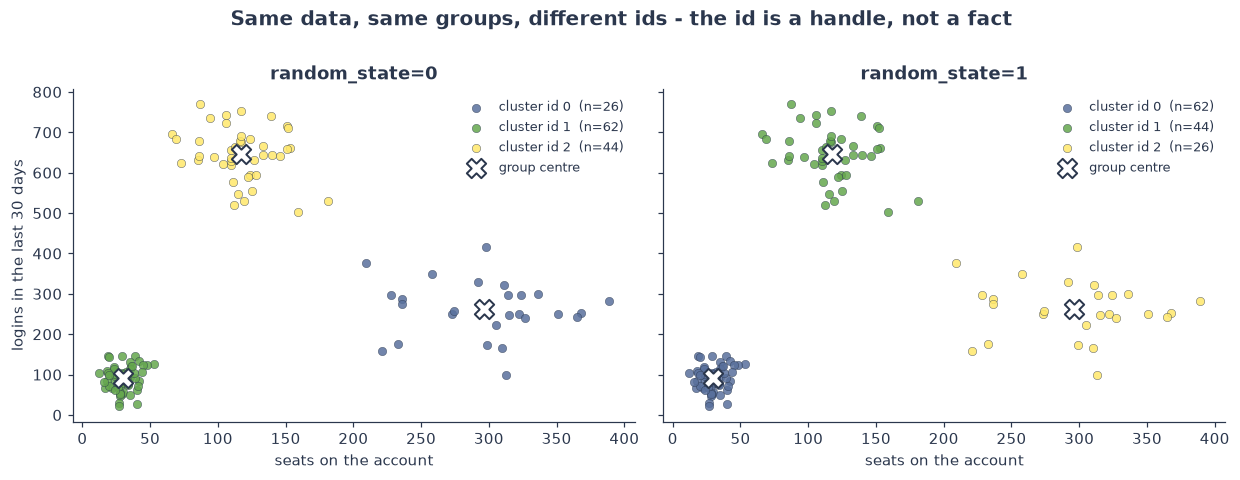

One more honesty note, because a client will eventually ask. KMeans measures DISTANCE, so the
column scales matter: logins run to ~1,200 and seats to ~400, so the login axis is doing most of
the work here. Rescale the columns and you can get different groups from the same accounts.
That is a second reason a cluster id is not a fact about a customer - it is a fact about a
particular table, a particular scaling and a particular k that a human chose.


In [9]:
# --- Figure: the same 132 accounts, coloured by the id KMeans gave them - twice, with the two seeds.
# --- Identical grouping, permuted ids. The picture makes the point faster than the arrays do.

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3), sharex=True, sharey=True)
PALETTE = [VSP["navy"], VSP["green"], VSP["yellow"]]

for ax, model, title in ((axes[0], km, "random_state=0"), (axes[1], km_reseeded, "random_state=1")):
    for k in range(3):
        sel = model.labels_ == k
        ax.scatter(accounts[sel, 0], accounts[sel, 1], s=30, color=PALETTE[k], alpha=0.85,
                   edgecolor=VSP["ink"], linewidth=0.3, label=f"cluster id {k}  (n={int(sel.sum())})")
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], marker="X", s=160,
               color="white", edgecolor=VSP["ink"], linewidth=1.3, zorder=4, label="group centre")
    ax.set_xlabel("seats on the account")
    ax.set_title(title, fontsize=11.5, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8.2)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("logins in the last 30 days")
fig.suptitle("Same data, same groups, different ids - the id is a handle, not a fact",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

print("One more honesty note, because a client will eventually ask. KMeans measures DISTANCE, so the")
print("column scales matter: logins run to ~1,200 and seats to ~400, so the login axis is doing most of")
print("the work here. Rescale the columns and you can get different groups from the same accounts.")
print("That is a second reason a cluster id is not a fact about a customer - it is a fact about a")
print("particular table, a particular scaling and a particular k that a human chose.")

### Stop 3, read line by line

| | |
|---|---|
| **Takes in** | one row per account, features only — **no label column exists**, and none is needed |
| **Kicks out** | a 1-d int array of ids, one per row: `array([2, 0, 2, 2, 0, 2, …])`, plus the group centres |
| **What it is** | a **partition**: which accounts resemble which, on the columns you happened to feed it, at the `k` you happened to choose |
| **What it is NOT** | ① ordered — `2` is not better than `1` · ② stable — re-seed and the ids permute (proved above) · ③ named — an unnamed id is worth nothing to marketing · ④ a segment *strategy* — a human still has to look at the groups and decide two of them are the same thing |
| **Say this** | *"The model found three groups; the ids are arbitrary handles. Here are their profiles — you name them, and then we check they differ on something you'd actually do differently."* |
| **Go deeper** | `notebooks/unsupervised/01_Unsupervised_KMeans_Clustering.ipynb` — choosing `k`, the elbow plot, and what "distance" means here |

**The pre-sales consequence.** Because the deliverable is *named groups*, the clustering project has a human
review step in it by construction. Price it. Clients who bought "a clustering model" and received a column of
integers are the single most common source of the sentence *"we tried AI before and it didn't do anything."*

## Stop 4 · A recommender → **a ranked short list**

*Model: co-occurrence over 600 accounts' product ownership + a `NearestNeighbors` fit · label column: **none** —
the signal is what got bought together.*

The fourth shape is the odd one out: not a number about one thing, but an **ordering of several things** for one
entity. That changes what the score means. In the table below, `confidence` is *"of the accounts that own the
analytics add-on, this fraction also own X"* — and `lift` is that fraction divided by how common X is anyway.

Which column you rank by **is a business decision, and it changes the recommendation**. That is not a flaw in
the model; it is the part of the job that belongs to you.

In [10]:
# --- STOP 4: recommender. "Accounts that own the analytics add-on also own..." - the association-rule
# --- shape, computed from a plain ownership matrix. Four lines of pandas do the rule arithmetic.

rng = np.random.default_rng(71)
PRODUCTS = ["core platform", "analytics add-on", "premium support", "SSO / security",
            "training package", "extra storage", "API tier"]
BASE_RATE = np.array([0.93, 0.38, 0.30, 0.26, 0.22, 0.31, 0.18])       # how common each product is
TRAVELS_WITH = {("analytics add-on", "extra storage"): 0.52,           # pairs that genuinely co-occur
                ("analytics add-on", "API tier"): 0.40,
                ("SSO / security", "premium support"): 0.31,
                ("training package", "premium support"): 0.24}

N_BASKETS = 600
owned = rng.random((N_BASKETS, len(PRODUCTS))) < BASE_RATE
col = {p: i for i, p in enumerate(PRODUCTS)}
for (a, b), rate in TRAVELS_WITH.items():
    bump = owned[:, col[a]] & (rng.random(N_BASKETS) < rate)
    owned[bump, col[b]] = True

print("RAW INPUT - the ownership matrix: one row per account, one column per product, True/False.")
print(f"shape {owned.shape}   dtype {owned.dtype}   first 3 rows:")
print(repr(owned[:3]))
print("        Note the table SHAPE is different from every other stop: a recommender does not want one")
print("        row per entity with features - it wants the interaction history itself.")
print()

ANTECEDENT = "analytics add-on"
has_it = owned[:, col[ANTECEDENT]]
support = owned.mean(axis=0)                 # how common each product is overall
confidence = owned[has_it].mean(axis=0)      # ...among accounts that own the antecedent
rules = (pd.DataFrame({"consequent": PRODUCTS,
                       "support": support.round(3),
                       "confidence": confidence.round(3),
                       "lift": (confidence / support).round(2)})
         .query("consequent != @ANTECEDENT")
         .reset_index(drop=True))

print(f'RAW OUTPUT - association rules for "accounts that own {ANTECEDENT!r} also own ..."')
print(f"            ({int(has_it.sum())} of {N_BASKETS} accounts own it)")
print()
print("RANKED BY CONFIDENCE  <- what the client's dashboard will do by default")
display(rules.sort_values("confidence", ascending=False).reset_index(drop=True))
print("RANKED BY LIFT        <- the same numbers, a different recommendation")
display(rules.sort_values("lift", ascending=False).reset_index(drop=True))

_by_conf = rules.sort_values("confidence", ascending=False).iloc[0]
_by_lift = rules.sort_values("lift", ascending=False).iloc[0]
print(f"[TRAP] top by confidence: {_by_conf['consequent']:<17} confidence {_by_conf['confidence']:.3f}  "
      f"lift {_by_conf['lift']:.2f}")
print(f"       top by lift      : {_by_lift['consequent']:<17} confidence {_by_lift['confidence']:.3f}  "
      f"lift {_by_lift['lift']:.2f}")
print(f"       {_by_conf['consequent']} wins on confidence because {100 * _by_conf['support']:.0f}% of ALL "
      f"accounts own it - it is the product\n       everybody has. A recommendation nobody can act on is not "
      f"a recommendation. Lift asks the\n       better question: is this MORE likely for these accounts than "
      f"for everyone?")
print()

# The same ranking, from a real sklearn fit: which products behave most like the antecedent?
item_vectors = owned.T.astype(float)                                   # one row per PRODUCT
nn = NearestNeighbors(n_neighbors=4, metric="cosine").fit(item_vectors)
dist, ind = nn.kneighbors(item_vectors[col[ANTECEDENT]].reshape(1, -1))
print("RAW OUTPUT - NearestNeighbors.kneighbors(): two arrays, distances and row indices.")
print(f" distances {np.round(dist, 4)}")
print(f" indices   {ind}")
print(" decoded  : " + " > ".join(f"{PRODUCTS[j]} ({1 - d:.2f})" for d, j in zip(dist[0], ind[0])))
print("        Rank 1 is the antecedent itself at distance 0.0 - the raw output includes the thing you")
print("        asked about, and nothing stops it recommending a product the account already owns. Filtering")
print("        that is application code, not model output, and forgetting it is the classic demo bug.")

RAW INPUT - the ownership matrix: one row per account, one column per product, True/False.
shape (600, 7)   dtype bool   first 3 rows:
array([[ True, False, False, False,  True,  True, False],
       [ True, False,  True, False, False, False, False],
       [ True,  True, False, False, False,  True, False]])
        Note the table SHAPE is different from every other stop: a recommender does not want one
        row per entity with features - it wants the interaction history itself.

RAW OUTPUT - association rules for "accounts that own 'analytics add-on' also own ..."
            (222 of 600 accounts own it)

RANKED BY CONFIDENCE  <- what the client's dashboard will do by default


,consequent,support,confidence,lift
0,core platform,0.943,0.932,0.99
1,extra storage,0.447,0.694,1.55
2,API tier,0.275,0.455,1.65
3,premium support,0.425,0.437,1.03
4,SSO / security,0.262,0.284,1.08
5,training package,0.235,0.225,0.96


RANKED BY LIFT        <- the same numbers, a different recommendation


,consequent,support,confidence,lift
0,API tier,0.275,0.455,1.65
1,extra storage,0.447,0.694,1.55
2,SSO / security,0.262,0.284,1.08
3,premium support,0.425,0.437,1.03
4,core platform,0.943,0.932,0.99
5,training package,0.235,0.225,0.96


[TRAP] top by confidence: core platform     confidence 0.932  lift 0.99
       top by lift      : API tier          confidence 0.455  lift 1.65
       core platform wins on confidence because 94% of ALL accounts own it - it is the product
       everybody has. A recommendation nobody can act on is not a recommendation. Lift asks the
       better question: is this MORE likely for these accounts than for everyone?

RAW OUTPUT - NearestNeighbors.kneighbors(): two arrays, distances and row indices.
 distances [[0.     0.3686 0.416  0.4723]]
 indices   [[1 5 0 6]]
 decoded  : analytics add-on (1.00) > extra storage (0.63) > core platform (0.58) > API tier (0.53)
        Rank 1 is the antecedent itself at distance 0.0 - the raw output includes the thing you
        asked about, and nothing stops it recommending a product the account already owns. Filtering
        that is application code, not model output, and forgetting it is the classic demo bug.


### Stop 4, read line by line

| | |
|---|---|
| **Takes in** | **interaction history** — who bought/used/loaded what — in a different table shape from the other three: one row per account per product, not one row per account with features |
| **Kicks out** | an **ordered** list of items with relative scores. Two arrays from `kneighbors`, or a frame of rules |
| **What it is** | *"Among the 222 accounts that own the analytics add-on, 69% also own extra storage — 1.55× the rate for accounts generally."* An ordering, and the ordering is the product |
| **What it is NOT** | ① a probability — `0.694` is a share of a peer group, not the chance this account buys · ② comparable across rows — `0.69` here and `0.69` for a different antecedent are different quantities · ③ self-filtering — the raw output happily ranks what they already own · ④ one ranking — confidence and lift disagree, and both are correct answers to different questions |
| **Say this** | *"Of accounts like this one, 69% also own extra storage — call it a top-three suggestion, not a forecast. And the ranking depends on whether you want the most likely add-on or the most unusually likely one; that's your call, not the model's."* |
| **Go deeper** | `notebooks/unsupervised/07_Unsupervised_Apriori.ipynb` — the full Apriori algorithm over baskets, with support/confidence/lift computed properly at scale. **Caveat:** that notebook imports `mlxtend`, which is deliberately **not** in the MOD-1 venv — read it rendered, or `pip install mlxtend` in your own environment |

**How a recommender gets judged**, since it is the one output above where accuracy is the wrong question: not
"was item 1 correct" but *"did the short list contain something useful, and did the human take it?"* Which is
why the discovery question is **"how many slots are there?"** — five offers on a screen, three suggestions in a
rep's sidebar, one truckload of parts. Capacity defines the deliverable.

---

## The four outputs side by side — the table to keep

| Job | Takes in | Kicks out | How to read it | The trap |
|---|---|---|---|---|
| **Classify / propensity** | features + a `yes/no` label column | `array([[0.27, 0.73]])` — one probability per class, summing to 1 | *"of deals scored near 0.73, about 73 in 100 close"* — a long-run frequency for lookalikes | reading it as a verdict on **this** row; reading column 0 when you meant column 1; assuming it is calibrated when nobody checked |
| **Regress** | features + a **numeric** label column | `array([29374.70441993])` — one number per row | *"about $29,000 a year, typically within ±$4,000"* — the number **and** the miss, in the client's units | quoting the number without units, without a miss, or outside the range it was trained on |
| **Cluster** | features, **no label column** | `array([2, 1, 2, 2, 1, …])` — one nominal id per row | *"three groups; here are their profiles — you name them"* | treating the id as ordered, stable or meaningful; shipping ids instead of names |
| **Recommend** | interaction history (a different table shape) + context | an **ordered** list with relative scores: `extra storage 0.69 > API tier 0.46 > …` | *"rank 1 beats rank 2"* — relative, within this list, for this entity | reading the score as a probability; ranking by the wrong column; forgetting to filter what they already own |

**The one-sentence version of the whole segment:** *the model's output is evidence, and the decision is a
separate object that a human owns.* The threshold, the units, the group names and the number of slots are all
**client-side choices** — and being the person in the room who says so is worth more than knowing which model
was fitted.

In [11]:
# --- The four outputs as Python objects, side by side. Same four fitted models as above; this cell
# --- just asks each one for one row of output and reports what came back.

one_deal = clf.predict_proba(X_open[[2]])                # #4127 - the drill's deal
one_number = reg.predict(NEW_ACCOUNT)                    # the 140-seat account
one_id = km.labels_[:1]                                  # the first account's group id
one_list = (rules.sort_values("lift", ascending=False)
            .head(3)[["consequent", "lift"]]
            .reset_index(drop=True))                     # a top-3 ranked list

print("=" * 104)
print(f"{'JOB':<22}{'OBJECT':<14}{'SHAPE':<12}{'DTYPE':<10}ONE ROW OF OUTPUT")
print("=" * 104)
print(f"{'classify/propensity':<22}{'ndarray':<14}{str(one_deal.shape):<12}{str(one_deal.dtype):<10}"
      f"{np.round(one_deal, 4).tolist()}")
print(f"{'regress':<22}{'ndarray':<14}{str(one_number.shape):<12}{str(one_number.dtype):<10}"
      f"{np.round(one_number, 2).tolist()}")
print(f"{'cluster':<22}{'ndarray':<14}{str(one_id.shape):<12}{str(one_id.dtype):<10}"
      f"{one_id.tolist()}")
print(f"{'recommend':<22}{'DataFrame':<14}{str(one_list.shape):<12}{'mixed':<10}"
      f"{list(zip(one_list['consequent'], one_list['lift']))}")
print("=" * 104)
print("Four fitted models, four objects, one client. If you can say what each object IS and what it is NOT,")
print("you have OUT-1.2. If you can also say what you would ask next, you have most of ASM-1.")
print()

# --- SI-6: every 'go deeper' path this notebook cites, verified against the filesystem.
GO_DEEPER = {
    "classify / propensity": "notebooks/supervised/02_Supervised_Logistic_Regression.ipynb",
    "regress": "notebooks/supervised/01_Supervised_Linear_Regression.ipynb",
    "cluster": "notebooks/unsupervised/01_Unsupervised_KMeans_Clustering.ipynb",
    "recommend": "notebooks/unsupervised/07_Unsupervised_Apriori.ipynb",
}
print("GO DEEPER - the repo notebooks behind each stop (paths verified, not remembered):")
for _job, _rel in GO_DEEPER.items():
    _exists = (REPO_ROOT / _rel).is_file()
    print(f"  [{'PASS' if _exists else 'FAIL'}] {_job:<22} {_rel}")
print("        The first three run in this venv as they are. The Apriori one imports mlxtend, which MOD-1")
print("        deliberately does not install (SI-24) - read it rendered, or install mlxtend yourself.")

JOB                   OBJECT        SHAPE       DTYPE     ONE ROW OF OUTPUT
classify/propensity   ndarray       (1, 2)      float64   [[0.27, 0.73]]
regress               ndarray       (1,)        float64   [29374.7]
cluster               ndarray       (1,)        int32     [2]
recommend             DataFrame     (3, 2)      mixed     [('API tier', 1.65), ('extra storage', 1.55), ('SSO / security', 1.08)]
Four fitted models, four objects, one client. If you can say what each object IS and what it is NOT,
you have OUT-1.2. If you can also say what you would ask next, you have most of ASM-1.

GO DEEPER - the repo notebooks behind each stop (paths verified, not remembered):
  [PASS] classify / propensity  notebooks/supervised/02_Supervised_Logistic_Regression.ipynb
  [PASS] regress                notebooks/supervised/01_Supervised_Linear_Regression.ipynb
  [PASS] cluster                notebooks/unsupervised/01_Unsupervised_KMeans_Clustering.ipynb
  [PASS] recommend              notebooks

---

# Segment 3 — Interpretation drill: "the model says 0.73" *(15 min)*

**How this runs.** The instructor plays the client; participants answer; the group critiques the answer against
the model answer. Before any of that, **the pre-work sentences get read back** — most of them will say "73%
chance" and stop, and the drill is about what that does and does not license.

The deal is not hypothetical: `#4127` is a row in the pipeline table from safari stop 1, and `0.73` is that
model's own output on it. You can see the features it was scored on.

### The scenario

> **Scenario.** A client's sales org bought a lead-scoring model. In the pipeline review, deal #4127 shows a score of **0.73**. The VP of Sales asks you: *"0.73 — so this deal is basically won, right? Should we stop working it?"*

Answer in **three parts** — what it is, what it's for, what you would ask next. That shape is not decoration:
it is the shape the `ASM-1` mock conversation is graded on, and it is the shape that stops you either
over-claiming ("yes, it's basically won") or hiding ("well, models are complicated").

**Then the two curveballs**, which the instructor drops in if there is time:

> *"Another deal says 0.51."*
>
> *"Our forecasting model says 8.2."*

Fill in the next cell. **Then** run the answer-key cell below it — not before.

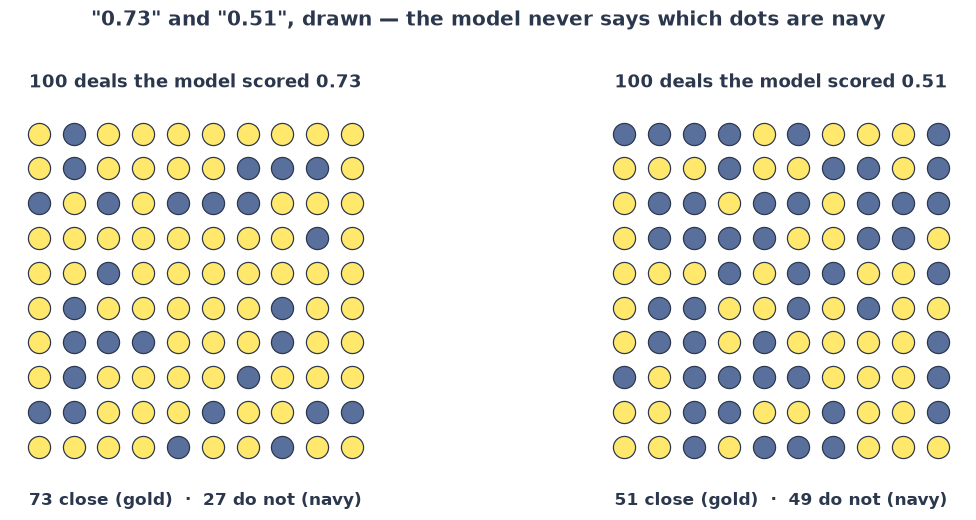

Use the left panel on the VP of Sales, in this order:
  1. "Yes - 73 of these close."                     (you are agreeing with them; do this first)
  2. "And 27 of them do not."                       (the sentence they have not had said to them)
  3. "The model cannot tell you which is which -    (this is the whole answer to "should we
      that is what working the deal is for."          stop working it?")

The right panel is curveball 1. At 0.51 the picture is a coin, and the honest sentence is that the
model has told you it does not know. Dressing that up as 'slightly favourable' is how trust dies.


In [12]:
# --- Figure: what 0.73 actually looks like. One hundred deals scored 0.73, and one hundred
# --- scored 0.51. The picture the VP of Sales needs, and it takes four seconds to draw on a whiteboard.

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))

for ax, p, title in ((axes[0], 0.73, "100 deals the model scored 0.73"),
                     (axes[1], 0.51, "100 deals the model scored 0.51")):
    rng_dots = np.random.default_rng(int(p * 100))          # seeded: the same picture every run
    n_lost = int(round((1 - p) * 100))
    lost = set(rng_dots.permutation(100)[:n_lost].tolist())  # scattered, because losses are not ordered
    for i in range(100):
        r, c = divmod(i, 10)
        is_lost = i in lost
        ax.scatter(c, -r, s=210,
                   color=VSP["navy"] if is_lost else VSP["yellow"],
                   edgecolor=VSP["ink"], linewidth=0.8, zorder=3)
    ax.set_xlim(-0.8, 9.8)
    ax.set_ylim(-9.8, 0.8)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.text(4.5, -10.30, f"{100 - n_lost} close (gold)  ·  {n_lost} do not (navy)", ha="center", va="top",
            fontsize=11, color=VSP["ink"], fontweight="bold")

fig.suptitle('"0.73" and "0.51", drawn — the model never says which dots are navy',
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Use the left panel on the VP of Sales, in this order:")
print('  1. "Yes - 73 of these close."                     (you are agreeing with them; do this first)')
print('  2. "And 27 of them do not."                       (the sentence they have not had said to them)')
print('  3. "The model cannot tell you which is which -    (this is the whole answer to "should we')
print('      that is what working the deal is for."          stop working it?")')
print()
print("The right panel is curveball 1. At 0.51 the picture is a coin, and the honest sentence is that the")
print("model has told you it does not know. Dressing that up as 'slightly favourable' is how trust dies.")

In [13]:
# --- THE DRILL. Three parts, then the two curveballs. Write yours BEFORE running the key cell.
#     Nothing here is graded exactly - it is probed for the concepts that make an answer client-safe,
#     with three verdicts per part: MATCH / DEFENSIBLE / MISS, each with a reason.
#
#     Say it out loud as you type it. If it does not survive being said out loud, it will not survive
#     a VP of Sales.

# Part 1 - WHAT IT IS. What is 0.73, exactly? (60+ characters)
DRILL_WHAT_IT_IS = ""

# Part 2 - WHAT IT'S FOR. What does the number license the client to do? (60+ characters)
DRILL_WHAT_ITS_FOR = ""

# Part 3 - WHAT YOU WOULD ASK NEXT. Real questions, with question marks. (60+ characters)
DRILL_NEXT_QUESTIONS = ""

# Curveball 1 - the client says: "Another deal says 0.51."  (40+ characters)
CURVEBALL_051 = ""

# Curveball 2 - the client says: "Our forecasting model says 8.2."  (40+ characters)
CURVEBALL_82 = ""

# ---------------------------------------------------------------- checker (do not edit below)
_answers = {
    "part 1 - what it is": (DRILL_WHAT_IT_IS, 60),
    "part 2 - what it's for": (DRILL_WHAT_ITS_FOR, 60),
    "part 3 - what to ask next": (DRILL_NEXT_QUESTIONS, 60),
    "curveball - 0.51": (CURVEBALL_051, 40),
    "curveball - 8.2": (CURVEBALL_82, 40),
}
MY_DRILL = {k: " ".join(v[0].split()) for k, v in _answers.items()}

_short = [(k, len(MY_DRILL[k]), n) for k, (_, n) in _answers.items() if len(MY_DRILL[k]) < n]
if _short:
    for _k, _have, _need in _short:
        print(f"[TODO] {_k}: {_need}+ characters (you have {_have}).")
    print("\n       The three parts are required; the two curveballs are worth doing even if the room runs")
    print("       out of time, because ASM-1's client does not run out of time. Nothing saves until all")
    print("       five are in - and the key cell below still runs, it just has nothing of yours to grade.")
else:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    _path = OUT_DIR / f"drill_073_{getpass.getuser()}.json"
    _path.write_text(json.dumps({
        "lesson": "LSN-1.2", "serves": ["OUT-1.2"], "assessment": "ASM-1",
        "artifact": "interpretation drill: 'the model says 0.73' + two curveballs",
        "user": getpass.getuser(),
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
        "scenario": ("A client's sales org bought a lead-scoring model. In the pipeline review, deal #4127 "
                     "shows a score of 0.73. The VP of Sales asks you: \"0.73 \u2014 so this deal is basically "
                     "won, right? Should we stop working it?\""),
        "answers": MY_DRILL,
    }, indent=2))
    print("[PASS] Five answers committed.")
    print(f"[SAVED] {_path.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
    print("        Now run the key cell below. Read your pre-work sentence next to part 1 - the delta")
    print("        between those two lines is what this hour was for.")

[TODO] part 1 - what it is: 60+ characters (you have 0).
[TODO] part 2 - what it's for: 60+ characters (you have 0).
[TODO] part 3 - what to ask next: 60+ characters (you have 0).
[TODO] curveball - 0.51: 40+ characters (you have 0).
[TODO] curveball - 8.2: 40+ characters (you have 0).

       The three parts are required; the two curveballs are worth doing even if the room runs
       out of time, because ASM-1's client does not run out of time. Nothing saves until all
       five are in - and the key cell below still runs, it just has nothing of yours to grade.


In [14]:
# --- THE ANSWER KEY + GRADER. Run this AFTER the cell above.
# --- Three verdicts per part - MATCH / DEFENSIBLE / MISS - because "right/wrong" is not how a
# --- client conversation grades, and a defensible answer that stops one sentence early is the
# --- commonest real outcome, not a failure.

KEY = [
    dict(
        part="part 1 - what it is",
        plan=("What it is: 0.73 is the model's estimated probability that this deal closes, given the "
              "features it saw. If the model is well calibrated, of 100 deals scored around 0.73, roughly "
              "73 close \u2014 and 27 don't. It is a betting line, not a verdict on this deal."),
        core=("probab", "likelihood", "odds", "chance", "in 100", "out of 100", "of 100", "per 100",
              "73 of", "73 out of", "73 in "),
        second=("not a verdict", "not certain", "not a promise", "not a guarantee", "no guarantee",
                "27", "don't close", "do not close", "doesn't close", "does not close", "lost",
                "betting", " bet ", "long run", "over many", "similar deals", "deals like", "lookalike",
                "calibrat", "frequency", "average"),
        core_name="the noun: a probability (or the 73-in-100 frequency reading)",
        second_name="the other half: what it is not - a verdict on THIS deal, and the 27 that lose",
        match="Both halves. This is the answer that survives a VP of Sales, because it agrees with them "
              "first (73 do close) and then says the thing they have not heard (27 do not, and nobody "
              "knows which).",
        defensible="You named the right noun and stopped one sentence early. 'A 73% chance' is not wrong - "
                   "it is incomplete, and the missing half is the half that stops them cancelling the "
                   "follow-up call. Add: 'and 27 in 100 like this one do not close, and the model cannot "
                   "say which.'",
        miss="The noun is missing. If 0.73 is described as a rating, a grade, a quality score or the "
             "model's confidence, the client keeps their original reading - that it is a verdict with a "
             "decimal point on it. Start with the word 'probability' (or 'of 100 deals like this, 73').",
        note="A trap worth naming out loud: 0.73 is NOT the model's accuracy. Those are different numbers "
             "and LSN-1.3 owns the second one. If your sentence contains the word 'accurate', check which "
             "one you meant.",
    ),
    dict(
        part="part 2 - what it's for",
        plan=("What it's for: ranking and prioritizing \u2014 a 0.73 deserves attention before a 0.31. It says "
              "nothing about why, and it never says \"stop working it.\""),
        core=("rank", "priorit", "sort", "orderi", "in order of", "queue", "triage", "work list",
              "worklist", "top of", "before a", "before the", "above", "compare", "which deals"),
        second=("nothing about why", "not why", "no reason", "doesn't say why", "does not say why",
                "never says", "not stop", "don't stop", "do not stop", "keep working", "no advice",
                "what to do", "not a decision", "not an action", "why"),
        core_name="the use: ranking and prioritising a limited day",
        second_name="the limits: it says nothing about WHY, and it never says 'stop working it'",
        match="Both. Note that you have now answered the VP's actual question - 'should we stop working "
              "it?' - without ever telling them what to do with their pipeline, which is not your call to "
              "make on their behalf.",
        defensible="You have the use right and left the limits implicit. In a real meeting the limits are "
                   "the half that gets quoted back at you three months later, so say them: the score "
                   "carries no reason, and it never recommends an action.",
        miss="Nothing about ranking. This is the number's entire job: #4127 at 0.73 gets attention before "
             "#4108 at 0.31, because the client can only work so many deals before Friday. Without the "
             "ranking frame, a probability is trivia.",
    ),
    dict(
        part="part 3 - what to ask next",
        plan=("The next questions to ask: Is the score calibrated \u2014 when it said 0.7 historically, did "
              "~70% actually close? What features feed it, and how fresh are they? What threshold and "
              "action has the client attached to the score?"),
        core=("calibrat", "when it said", "historically", "actually close", "back-test", "backtest",
              "track record", "how often", "held up", "hold up", "feature", "which columns", "what data",
              "inputs", "fresh", "stale", "how old", "updated", "refresh", "leak", "threshold", "cut-off",
              "cutoff", "what action", "and action", "act on", "who acts", "what happens", "capacity",
              "how many deals", "workflow"),
        second=(),
        core_name="the three families: calibration · features and freshness · threshold and action",
        second_name="",
        match="Two or more of the three families. This is the part that makes you the senior person in "
              "the room: you have turned their statement into a diagnostic, and every one of your "
              "questions is answerable by them today.",
        defensible="One family covered. Good instinct, thin coverage - the other two are where the "
                   "expensive surprises live. A stale feature makes a well-calibrated model quietly "
                   "wrong, and a threshold nobody set means the score is decorative.",
        miss="No questions, or none that a client could answer. The shape of a senior answer is "
             "'here is what it means, here is what it licenses, and here is what I would need to know' - "
             "and the third part is the one that gets you a second meeting.",
        note="Question marks matter more than they look: 'I would check calibration' is a task, "
             "'when the model said 0.7 last year, what fraction actually closed?' is a question a client "
             "can answer in the room.",
        families=dict(
            calibration=("calibrat", "when it said", "historically", "actually close", "back-test",
                         "backtest", "track record", "how often", "held up", "hold up"),
            features=("feature", "which columns", "what data", "inputs", "fresh", "stale", "how old",
                      "updated", "refresh", "leak"),
            action=("threshold", "cut-off", "cutoff", "what action", "and action", "act on", "who acts",
                    "what happens", "capacity", "how many deals", "workflow"),
        ),
    ),
    dict(
        part="curveball - 0.51",
        plan=("\"Another deal says 0.51.\" \u2014 near a coin flip; the model is telling you it doesn't know; "
              "don't dress it up."),
        core=("coin", "toss", "50/50", "50-50", "fifty", "doesn't know", "does not know", "no idea",
              "no signal", "no information", "uncertain", "uncertainty", "can't tell", "cannot tell",
              "no better than", "as good as", "flip"),
        second=("don't dress", "do not dress", "human", "escalat", "don't act", "do not act", "not enough",
                "abstain", "judgement", "judgment", " reps", "sales rep", "salesperson", "don't pretend",
                "do not pretend", "honest", "no decision", "other information", "more information"),
        core_name="the reading: a coin flip - the model is saying it does not know",
        second_name="the discipline: don't dress it up; the decision goes back to a human",
        match="Both. And the professional habit underneath it: a model that says 'I don't know' is being "
              "useful, and a system that has nowhere to put that answer is badly designed.",
        defensible="You called the coin flip. Now add what to DO with it, because the client will ask: "
                   "0.51 is not a small yes, it is an abstention - the deal goes to human judgement, and "
                   "nobody should be reporting it as 'leaning positive'.",
        miss="0.51 read as a weak-but-real signal. That is the trap: it is 51 in 100 versus 49 in 100, "
             "which is a coin. Treating it as information is how a model's credibility gets spent - and "
             "the honest sentence, 'the model doesn't know', is a sentence clients respect.",
    ),
    dict(
        part="curveball - 8.2",
        plan=("\"Our forecasting model says 8.2.\" \u2014 that's a regression output; 8.2 what? Units first, "
              "interpretation second \u2014 a number without units is not an answer."),
        core=("unit", "8.2 what", "measured in", "what scale", "per what", "of what", "what is it "
              "measuring", "what's it measuring", "8.2 of", "what does 8.2"),
        second=("regression", "a number", "don't interpret", "do not interpret", "can't interpret",
                "cannot interpret", "not an answer", "before", " ask", "meaningless", "no answer",
                "range", "over what period", "period"),
        core_name="the move: ask what 8.2 is measured in, before saying anything about it",
        second_name="the frame: it is a regression output, and a number without units is not an answer",
        match="Both. This is the shortest senior answer in the lesson: four words - 'eight point two "
              "what?' - and you have moved the conversation from decoration to specification.",
        defensible="You spotted that the units are missing. Close it with the reason: this is a regression "
                   "output, and a number with no units, no period and no typical miss is not an answer "
                   "yet - it is a placeholder.",
        miss="Interpreting 8.2 without knowing what it measures. Deals, weeks, percent, millions and "
             "'out of ten' are five different conversations, and picking one to be helpful is how a "
             "meeting ends up planning against a number nobody has defined.",
    ),
]


def verdict_for(item: dict, text: str) -> tuple:
    """Return (tag, reason, evidence) - three-verdict grading, concept-probed, never exact strings."""
    if not text:
        return ("[BLANK]", "You skipped this one. Go back, write it, then re-read this - reading the key "
                           "without committing an answer is preparation, not practice.", [])
    core_hits = hits(text, item["core"])
    second_hits = hits(text, item["second"]) if item["second"] else []
    if "families" in item:                                  # part 3 grades by family coverage
        covered = [name for name, pats in item["families"].items() if hits(text, pats)]
        if len(covered) >= 2:
            return "[MATCH]", item["match"], covered
        if len(covered) == 1:
            return "[DEFENSIBLE]", item["defensible"], covered
        return "[MISS]", item["miss"], covered
    if core_hits and second_hits:
        return "[MATCH]", item["match"], core_hits + second_hits
    if core_hits:
        return "[DEFENSIBLE]", item["defensible"], core_hits
    return "[MISS]", item["miss"], []


_mine = globals().get("MY_DRILL", {})
_tally = {"[MATCH]": 0, "[DEFENSIBLE]": 0, "[MISS]": 0, "[BLANK]": 0}
_verdicts = {}

for item in KEY:
    text = _mine.get(item["part"], "")
    tag, reason, evidence = verdict_for(item, text)
    _tally[tag] += 1
    _verdicts[item["part"]] = tag.strip("[]").lower()
    print("\n" + "-" * 104)
    print(f"{item['part'].upper()}")
    wrap("PLAN KEY", item["plan"] + "   [verbatim from the lesson plan]")
    wrap("LOOKS FOR", f"{item['core_name']}" +
         (f"  +  {item['second_name']}" if item["second_name"] else ""))
    if text:
        print(textwrap.fill(f'YOU WROTE "{text}"', width=104, initial_indent="  ",
                            subsequent_indent="    "))
    print(f"  VERDICT   {tag}")
    wrap("WHY", reason)
    if evidence:
        wrap("PICKED UP", ", ".join(str(e) for e in evidence))
    if item.get("note"):
        wrap("NOTE", item["note"])

# --- The genuine tie, awarded separately: it is not on the plan's key and it is the senior answer.
_p1 = _mine.get("part 1 - what it is", "")
if hits(_p1, ("calibrat", "might not be", "may not be", "just a score", "just a rank", "uncalibrated",
              "if it is calibrated", "if it's calibrated", "assuming it")):
    print("\n" + "-" * 104)
    wrap("[TIE]", "You hedged on whether 0.73 is really a probability at all. That is the genuine tie "
                  "from safari stop 1 and it is the strongest available answer: a well-fitted logistic "
                  "regression emits a probability, but a tuned tree score or a squashed decision function "
                  "may only RANK correctly while being wrong about the level. Both readings are defensible "
                  "until someone checks calibration - and saying so before the client builds a commission "
                  "plan on the number is the most senior sentence in this lesson.")

print("\n" + "=" * 104)
if _mine and _tally["[BLANK]"] == 0:
    print(f"YOUR DRILL: {_tally['[MATCH]']} match  ·  {_tally['[DEFENSIBLE]']} defensible  ·  "
          f"{_tally['[MISS]']} miss   (of 5)")
    print("Five out of five is not the bar. The bar is saying the three parts out loud, in order, while a")
    print("client pushes back - which is exactly what ASM-1's mock conversation puts you through. Read the")
    print("DEFENSIBLE reasons twice: they are the sentences you stopped one short of.")
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    _graded = OUT_DIR / f"drill_graded_{getpass.getuser()}.json"
    _graded.write_text(json.dumps({
        "lesson": "LSN-1.2", "serves": ["OUT-1.2"], "assessment": "ASM-1",
        "artifact": "'0.73' drill, graded against the lesson-plan model answer (match/defensible/miss)",
        "user": getpass.getuser(),
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
        "tally": {k.strip("[]").lower(): v for k, v in _tally.items()},
        "per_part": _verdicts,
    }, indent=2))
    print(f"[SAVED] {_graded.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
else:
    print("No tally: the drill cell above is not filled in, so this was a read-through of the key.")
    print("That is a fine way to prepare and a useless way to practise. Go back, write five answers,")
    print("re-run both cells, and let the DEFENSIBLE verdicts land - they are the interesting ones.")
print("=" * 104)


--------------------------------------------------------------------------------------------------------
PART 1 - WHAT IT IS
  PLAN KEY  What it is: 0.73 is the model's estimated probability that this deal closes, given the
            features it saw. If the model is well calibrated, of 100 deals scored around 0.73, roughly
            73 close — and 27 don't. It is a betting line, not a verdict on this deal.   [verbatim from
            the lesson plan]
  LOOKS FOR the noun: a probability (or the 73-in-100 frequency reading)  +  the other half: what it is
            not - a verdict on THIS deal, and the 27 that lose
  VERDICT   [BLANK]
  WHY       You skipped this one. Go back, write it, then re-read this - reading the key without
            committing an answer is preparation, not practice.
  NOTE      A trap worth naming out loud: 0.73 is NOT the model's accuracy. Those are different numbers
            and LSN-1.3 owns the second one. If your sentence contains the word 'accurat

### The model answer — the shape a pass looks like

*Verbatim from the lesson plan, so there is one canonical version of it in the repo:*

1. **What it is:** 0.73 is the model's estimated *probability* that this deal closes, given the features it saw.
   If the model is well calibrated, of 100 deals scored around 0.73, roughly 73 close — and 27 don't. It is a
   betting line, not a verdict on this deal.
2. **What it's for:** ranking and prioritizing — a 0.73 deserves attention before a 0.31. It says nothing about
   *why*, and it never says "stop working it."
3. **The next questions to ask:** Is the score calibrated — when it said 0.7 historically, did ~70% actually
   close? What features feed it, and how fresh are they? What threshold and action has the client attached to
   the score?

**Curveballs (time permitting):** *"Another deal says 0.51."* — near a coin flip; the model is telling you it
doesn't know; don't dress it up. *"Our forecasting model says 8.2."* — that's a regression output; 8.2 *what*?
Units first, interpretation second — a number without units is not an answer.

**Note that `#4108` in the safari's pipeline table scores `0.31`.** The plan's comparison is on screen:
`#4127` at 0.73 gets worked before `#4108` at 0.31, and that sentence — *ranking, not verdicts* — is the entire
commercial value of a propensity model. Notice also what part 2 does with the VP's actual question: it answers
*"should we stop working it?"* without ever telling the VP how to run their pipeline.

---

## Before you leave — no homework, and the `LSN-1.3` pre-work

**No homework for this lesson** (per the lesson plan). The output-reading skill is verified in the `ASM-1`
quiz. **Keep your corrected "0.73" sentence** — it is the seed of your mock pre-sales answers, and it lives in
`outputs/lsn-1.2/drill_073_*.json`.

| Next | `LSN-1.3` — Grading models: MAE, precision/recall, AUC (1.5 h session + 30 min pre-work) |
|---|---|
| **Pre-work 1** | Revisit your `LSN-0.3` base-rate notes (the 1-in-10,000 fraud detector) — *15 min*. Bring **one line**: why is a 99%-accurate detector on a rare event mostly false alarms? |
| **Pre-work 2** | Read the grading/metrics material — the `LSN-1.3` session deck — *15 min* |

**And the question this hour deliberately left open.** Every answer in the drill dodged one thing, and a good
client will notice: **is 0.73 any good?** You cannot know from the number. Not from one number, not from a
hundred of them, not from the model's own confidence in itself. You need to compare what it said against what
happened — which is a **metrics** question, and it is the next hour:

- *"73 in 100 close"* — did they? That is **calibration**, and it is measured, not assumed.
- *"About $29,000 a year, ±$4,000"* — that ±$4,000 has a name (**MAE**) and it has to be computed on data the
  model has **not** seen.
- *"We flagged these 40 deals"* — how many were real (**precision**) and how many did we miss (**recall**)?
  Two different kinds of wrong with two different price tags.

## Wrap-up — `OUT-1.2`

**You can now, on demand:**

- say what **training data** is in one sentence — a table where rows are examples, columns are features, and one
  column is the label — and say what the **presence or absence of that label column** decides (supervised vs
  unsupervised, `LSN-1.1`'s cluster job);
- take **one client table** and name three different projects hiding in it by circling a different column, and
  spot the two things that kill both: a label column that is **only populated for survivors**, and a feature
  that is **recorded after the outcome** (leakage);
- say what each of the four model types **takes in** and **kicks out**, and recognise the raw object on screen:
  a `(n, 2)` probability array · a one-number float array with units · an int array of nominal ids · an ordered
  list with relative scores;
- **interpret each one out loud, client-safe**: a probability is a long-run frequency for lookalikes and not a
  verdict · a number needs units, a period and a typical miss · a cluster id is an arbitrary handle until a
  human names it (it moves when you re-seed) · a ranking is only ever relative, and which column you rank by is
  a business decision;
- answer the `0.73` question in **three parts** — what it is, what it's for, what you would ask next — and
  handle both curveballs: `0.51` is the model saying it doesn't know, and `8.2` is not an answer until somebody
  says **8.2 what**;
- name the **genuine tie** and resolve it honestly: whether a 0–1 score is a calibrated probability or merely a
  ranking cannot be read off the number, so you ask.

**Next:** `LSN-1.3` grades these outputs, `LSN-1.4` trains a real one, `LSN-1.5` gives you the deep-learning
vocabulary, and `LSN-1.6` asks the data questions that decide whether any of it is buildable.